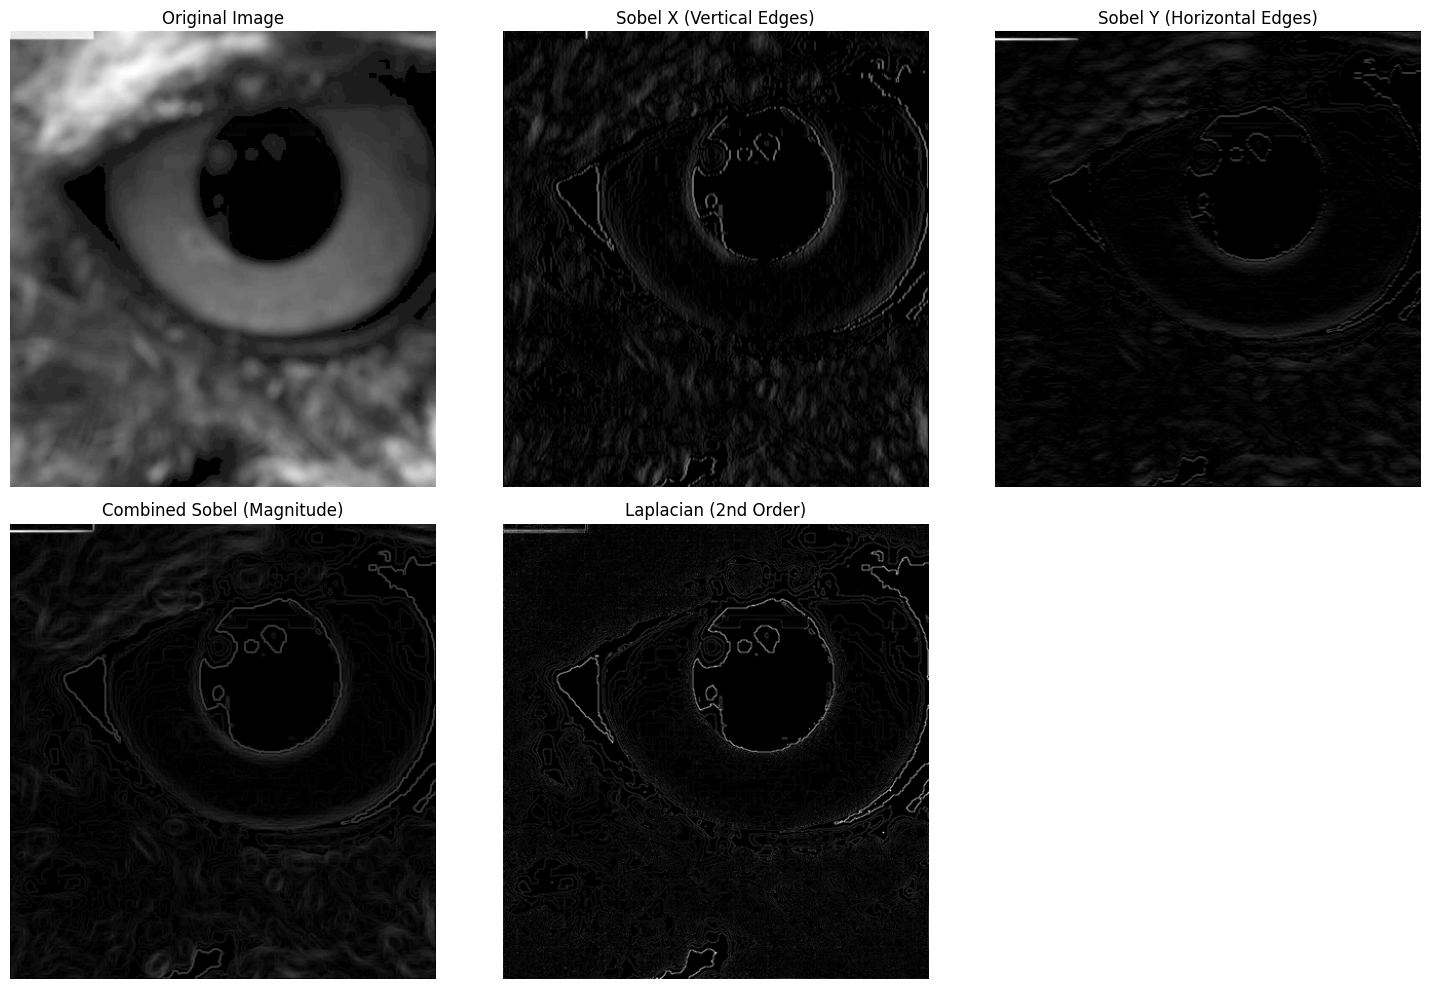

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read the image in Grayscale
# Replace 'moon.jfif' with your actual image path in Colab
img = cv2.imread('/content/unsharpe-iamge.png', cv2.IMREAD_GRAYSCALE)

# Step 2: Apply 1st Order Derivative (Sobel)
# dx=1, dy=0 means Sobel X. ksize=3 is the 3x3 matrix.
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

# dx=0, dy=1 means Sobel Y.
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Combine them using the magnitude formula
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

# Step 3: Apply 2nd Order Derivative (Laplacian)
laplacian = cv2.Laplacian(img, cv2.CV_64F)

# Step 4: Plot everything to observe the differences
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
# Using absolute values to display the negative slopes properly
plt.imshow(np.abs(sobel_x), cmap='gray')
plt.title("Sobel X (Vertical Edges)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(np.abs(sobel_y), cmap='gray')
plt.title("Sobel Y (Horizontal Edges)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel_combined, cmap='gray')
plt.title("Combined Sobel (Magnitude)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title("Laplacian (2nd Order)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 🔹 MRI Image URL (you can replace)
url = "https://cf-images.us-east-1.prod.boltdns.net/v1/jit/6168375534001/adef4c6d-9218-4c82-859b-1274e307545b/main/1280x720/7s7ms/match/image.jpg"

# Download image
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

img_array = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

# 🔹 Apply Gaussian Blur
blur = cv2.GaussianBlur(img, (5,5), 0)

# 🔹 Apply Canny Edge Detection
edges = cv2.Canny(blur, 50, 150)

# 🔹 Display Results
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original MRI Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(blur, cmap='gray')
plt.title("Blurred Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

plt.show()

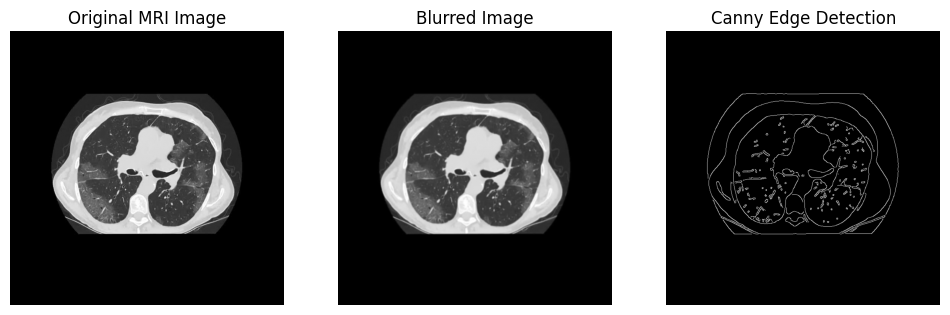

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Load image from URL
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcThAJSMl6C-Fp0QlPNAUwiqzqYgQoYH6_K6Zg&s"
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_GRAYSCALE)

# Add Gaussian Noise
noise = np.random.normal(0, 20, img.shape)
noisy_img = img + noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

# Sobel
sobel = cv2.Sobel(noisy_img, cv2.CV_64F, 1, 1, ksize=3)

# Prewitt
kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitt = cv2.filter2D(noisy_img, -1, kernelx)

# Laplacian
laplacian = cv2.Laplacian(noisy_img, cv2.CV_64F)

# Display
plt.figure(figsize=(12,6))
plt.subplot(2,2,1); plt.title("Original"); plt.imshow(img, cmap='gray')
plt.subplot(2,2,2); plt.title("Noisy"); plt.imshow(noisy_img, cmap='gray')
plt.subplot(2,2,3); plt.title("Sobel"); plt.imshow(sobel, cmap='gray')
plt.subplot(2,2,4); plt.title("Prewitt"); plt.imshow(prewitt, cmap='gray')

plt.figure(figsize=(5,5))
plt.title("Laplacian"); plt.imshow(laplacian, cmap='gray')
plt.show()

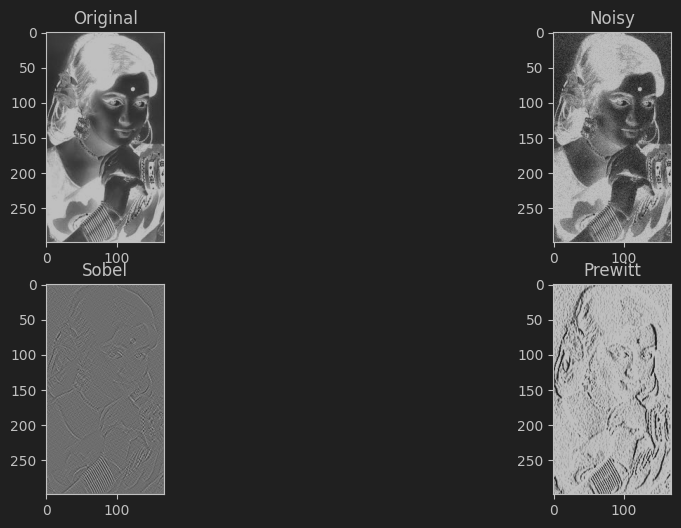
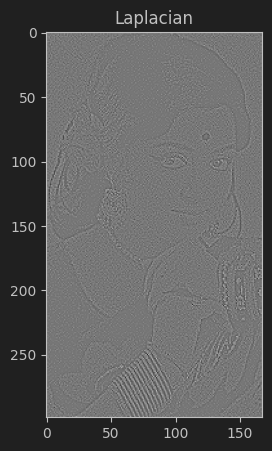

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Load image
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcThAJSMl6C-Fp0QlPNAUwiqzqYgQoYH6_K6Zg&s"
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_GRAYSCALE)

# Apply Sobel with different kernel sizes
sobel3 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel5 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobel7 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=7)

# Display
plt.figure(figsize=(12,6))
plt.subplot(1,4,1); plt.title("Original"); plt.imshow(img, cmap='gray')
plt.subplot(1,4,2); plt.title("ksize=3"); plt.imshow(sobel3, cmap='gray')
plt.subplot(1,4,3); plt.title("ksize=5"); plt.imshow(sobel5, cmap='gray')
plt.subplot(1,4,4); plt.title("ksize=7"); plt.imshow(sobel7, cmap='gray')
plt.show()

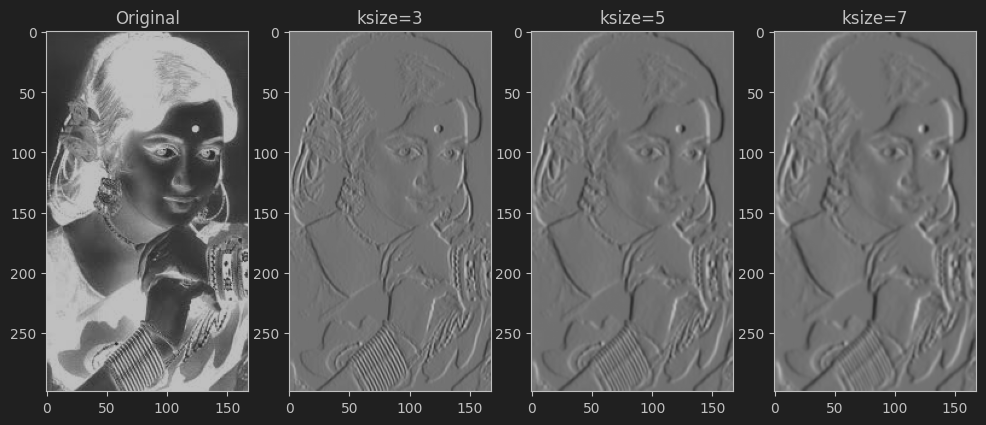

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Ensure 'sobel' is available from previous execution. If not, re-run relevant cells.
# In this case, 'sobel' is available in the kernel from cell 'y2bnFOMnvSbW'.

thresholds = [50, 100, 150]

plt.figure(figsize=(15, 5))

for i, thresh_val in enumerate(thresholds):
    # Apply binary thresholding
    _, binary_image = cv2.threshold(sobel.astype(np.uint8), thresh_val, 255, cv2.THRESH_BINARY)

    plt.subplot(1, len(thresholds), i + 1)
    plt.imshow(binary_image, cmap='gray')
    plt.title(f"Threshold: {thresh_val}")
    plt.axis('off')

plt.suptitle("Binary Thresholding on Sobel Edges")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

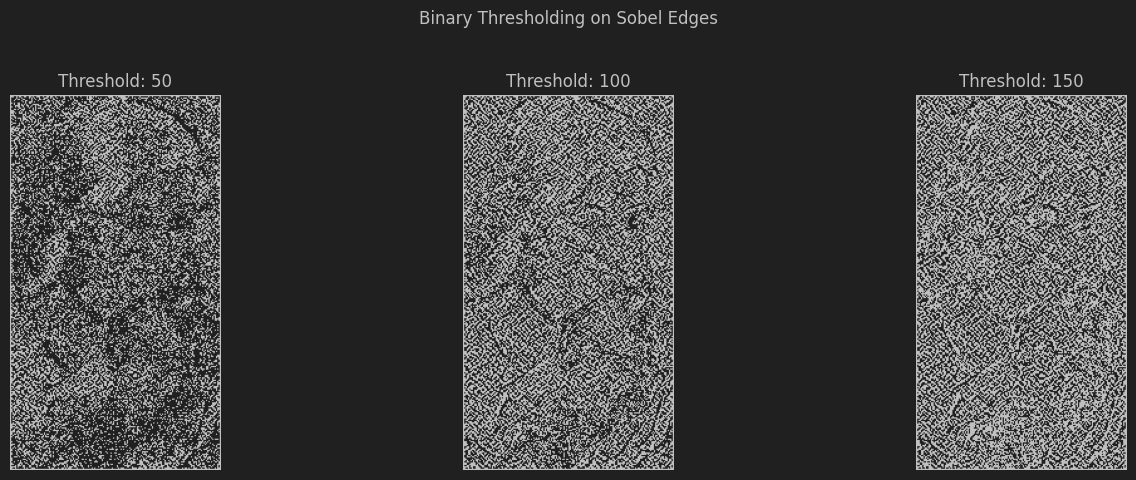

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ensure 'img' is available from previous execution. It is available from cell 'sW_5j-H8wCzA'.

# Apply Laplacian to the original image
laplacian_original = cv2.Laplacian(img, cv2.CV_64F)

# Apply Gaussian Blur to the image
blurred_img = cv2.GaussianBlur(img, (5, 5), 0)

# Apply Laplacian to the blurred image
laplacian_blurred = cv2.Laplacian(blurred_img, cv2.CV_64F)

# Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
# Using absolute values for display purposes as Laplacian can have negative values
plt.imshow(np.abs(laplacian_original), cmap='gray')
plt.title('Laplacian of Original Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(np.abs(laplacian_blurred), cmap='gray')
plt.title('Laplacian of Blurred Image')
plt.axis('off')

plt.suptitle('Laplacian Noise Sensitivity Study')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

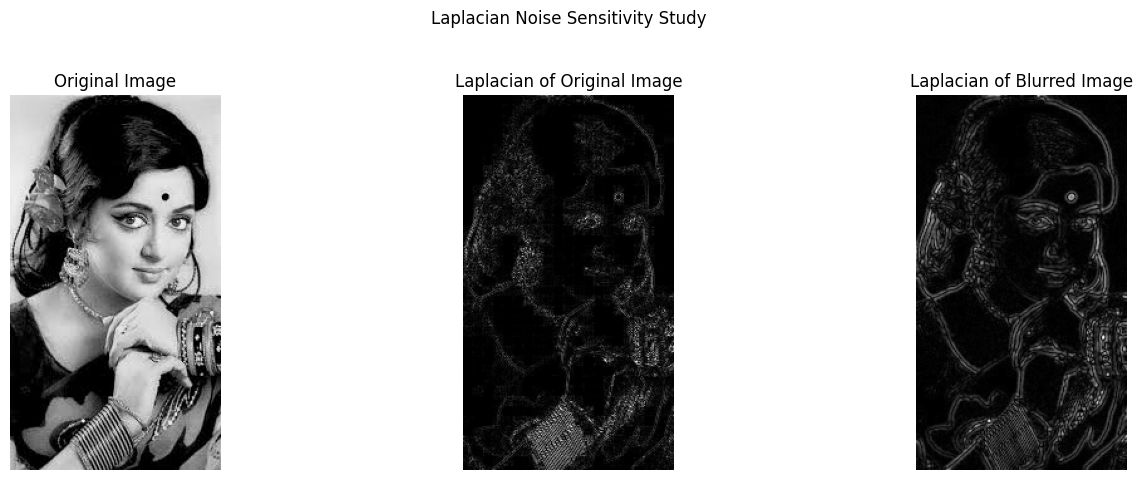